In [1]:
import os, requests, hashlib
from pathlib import Path
from tqdm import tqdm

os.system("df -h /kaggle/working")

WORKDIR = Path("/kaggle/working/boucheron_download")
WORKDIR.mkdir(parents=True, exist_ok=True)

FILES = [
    ("https://zenodo.org/records/7807466/files/C1.0_24hr_224_png_Labels.txt?download=1",
     "C1.0_24hr_224_png_Labels.txt", "c07787bd9def72d0519a49c02cb86f7c"),
    ("https://zenodo.org/records/7807466/files/Lat60_Lon60_Nans0_C1.0_24hr_png_224_features.csv?download=1",
     "Lat60_Lon60_Nans0_C1.0_24hr_png_224_features.csv", "95963729b452c90e3d0c3c1ec8822ba4"),
    ("https://zenodo.org/records/7807466/files/List_of_AR_in_Test_Data_by_AR.csv?download=1",
     "List_of_AR_in_Test_Data_by_AR.csv", "6f73d64b63429ee26876a156a734fa12"),
    ("https://zenodo.org/records/7807466/files/List_of_AR_in_Train_Data_by_AR.csv?download=1",
     "List_of_AR_in_Train_Data_by_AR.csv", "0b8b0b42eba839007bd40f163fc94455"),
    ("https://zenodo.org/records/7807466/files/List_of_AR_in_Validation_data_by_AR.csv?download=1",
     "List_of_AR_in_Validation_data_by_AR.csv", "fa192a397d0b582d372270af9db26393"),
    ("https://zenodo.org/records/7807466/files/README.md?download=1",
     "README.md", "ec8fa56a306a2e70862332dd94efb849"),
    ("https://zenodo.org/records/7807466/files/Test_Data_by_AR_png_224.csv?download=1",
     "Test_Data_by_AR_png_224.csv", "d6f0abaca77628def3462366e0937639"),
    ("https://zenodo.org/records/7807466/files/Train_Data_by_AR_png_224.csv?download=1",
     "Train_Data_by_AR_png_224.csv", "58442b71ebc3741a19cba18c75061017"),
    ("https://zenodo.org/records/7807466/files/Validation_Data_by_AR_png_224.csv?download=1",
     "Validation_Data_by_AR_png_224.csv", "2f4ec494748861ed110edf23b8bdf636"),
]

IMAGE_ARCHIVE = (
    "https://zenodo.org/records/7775776/files/Lat60_Lon60_Nans0_png_224.tar.gz?download=1",
    "Lat60_Lon60_Nans0_png_224.tar.gz",
    "c6498435e19705710ec4e1ec0c041a1d",
)

def md5sum(path, chunk=1024 * 1024):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()

def download_and_verify(url, filename, expected_md5, dest_dir=WORKDIR):
    dest = dest_dir / filename
    with requests.get(url, stream=True, allow_redirects=True, timeout=60) as r:
        r.raise_for_status()
        total = int(r.headers.get("Content-Length", 0))
        with open(dest, "wb") as f, tqdm(total=total, unit="B", unit_scale=True, desc=filename) as pbar:
            for chunk in r.iter_content(chunk_size=8 * 1024 * 1024):
                f.write(chunk)
                pbar.update(len(chunk))
    actual_md5 = md5sum(dest)
    ok = actual_md5 == expected_md5
    print(f"{filename}: {'MD5 OK' if ok else 'MD5 MISMATCH!'}")
    if not ok:
        raise RuntimeError(f"Checksum failed for {filename}")
    return dest

# small files first
for url, fname, md5 in FILES:
    download_and_verify(url, fname, md5)

# the big 13GB image file
download_and_verify(*IMAGE_ARCHIVE)

print("ALL FILES DOWNLOADED AND VERIFIED")
os.system(f"du -sh {WORKDIR}")
os.system("df -h /kaggle/working")

Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  156K   20G   1% /kaggle/working


C1.0_24hr_224_png_Labels.txt: 57.6MB [00:04, 13.1MB/s]


C1.0_24hr_224_png_Labels.txt: MD5 OK


Lat60_Lon60_Nans0_C1.0_24hr_png_224_features.csv: 465MB [01:02, 7.46MB/s]


Lat60_Lon60_Nans0_C1.0_24hr_png_224_features.csv: MD5 OK


...

Validation_Data_by_AR_png_224.csv: 6.24MB [00:00, 8.88MB/s]


Validation_Data_by_AR_png_224.csv: MD5 OK


Lat60_Lon60_Nans0_png_224.tar.gz: 100%|██████████| 13.0G/13.0G [59:21<00:00, 3.64MB/s]


Lat60_Lon60_Nans0_png_224.tar.gz: MD5 OK
ALL FILES DOWNLOADED AND VERIFIED
13G	/kaggle/working/boucheron_download
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G   13G  6.9G  65% /kaggle/working


0

In [2]:
metadata = '''{
  "title": "Boucheron Solar Flare Magnetograms C1.0 24hr 224px",
  "id": "esayasmelaku/solar-flare-boucheron-c1-224",
  "licenses": [{"name": "CC-BY-SA-4.0"}]
}'''

with open("/kaggle/working/boucheron_download/dataset-metadata.json", "w") as f:
    f.write(metadata)

print("metadata file created")

metadata file created


In [3]:
import os
os.system("kaggle datasets create -p /kaggle/working/boucheron_download --dir-mode zip")

Dataset creation error: The requested title "Boucheron Solar Flare Magnetograms C1.0 24hr 224px" is already in use by a dataset. Please choose another title.


0

In [4]:
import pandas as pd
from pathlib import Path

DATA_ROOT = Path("/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224")

# List everything
for item in DATA_ROOT.iterdir():
    print(item)

# Read the labels/features CSV
labels_csv = DATA_ROOT / "Lat60_Lon60_Nans0_C1.0_24hr_png_224_features.csv"
df = pd.read_csv(labels_csv, header=None)
print(df.shape)
print(df.head())

df.columns = [f"feature_{i}" for i in range(29)] + ["label", "flare_size", "filename"]
print(df["label"].value_counts())

/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/List_of_AR_in_Train_Data_by_AR.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/List_of_AR_in_Validation_data_by_AR.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/README.md
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/List_of_AR_in_Test_Data_by_AR.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Lat60_Lon60_Nans0_C1.0_24hr_png_224_features.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Validation_Data_by_AR_png_224.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Lat60_Lon60_Nans0_png_224
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Train_Data_by_AR_png_224.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Test_Data_by_AR_png_224.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/C1.0_24hr_224_png_Labels.txt
(950047, 32)
         0         1   

In [5]:
# Use .iloc to check by POSITION, regardless of current column names
for pos in [28, 29, 30]:
    print(f"Column at position {pos} (name: {df.columns[pos]}) value_counts (top 5):")
    print(df.iloc[:, pos].value_counts().head())
    print()

Column at position 28 (name: feature_28) value_counts (top 5):
feature_28
57734.0    33
57035.0    33
46787.0    33
53206.0    33
49586.0    33
Name: count, dtype: int64

Column at position 29 (name: label) value_counts (top 5):
label
0    759465
1    190582
Name: count, dtype: int64

Column at position 30 (name: flare_size) value_counts (top 5):
flare_size
0       759465
C1.1      9644
C1.2      8575
C1.3      7990
C1.0      7976
Name: count, dtype: int64



In [6]:
df.columns = [f"feature_{i}" for i in range(29)] + ["label", "flare_size", "filename"]
print(df.columns.tolist())
print(df[["label", "flare_size", "filename"]].head())

['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'label', 'flare_size', 'filename']
   label flare_size                                           filename
0      0          0  1064_hmi.M_720s.20100501_000000_TAI.1.magnetog...
1      0          0  1064_hmi.M_720s.20100501_001200_TAI.1.magnetog...
2      0          0  1064_hmi.M_720s.20100501_002400_TAI.1.magnetog...
3      0          0  1064_hmi.M_720s.20100501_003600_TAI.1.magnetog...
4      0          0  1064_hmi.M_720s.20100501_004800_TAI.1.magnetog...


label
0    759465
1    190582
Name: count, dtype: int64
label
0    79.94
1    20.06
Name: count, dtype: float64


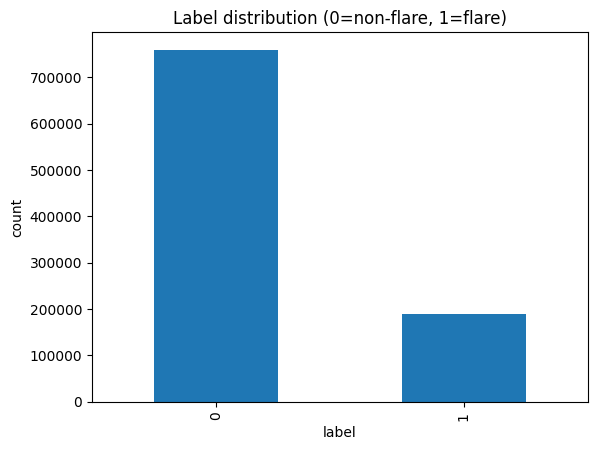

Number of unique ARs: 1570
count    1570.000000
mean      605.125478
std       316.406007
min         3.000000
25%       335.250000
50%       633.500000
75%       915.000000
max      1080.000000
dtype: float64


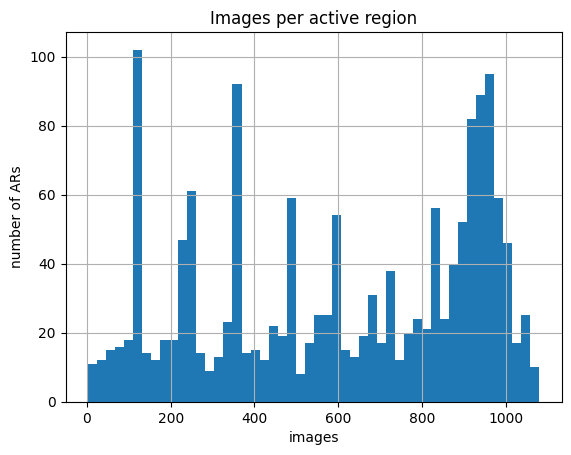

  AR_number    timestamp_str
0      1064  20100501_000000
1      1064  20100501_001200
2      1064  20100501_002400
3      1064  20100501_003600
4      1064  20100501_004800
5      1064  20100501_010000
6      1064  20100501_011200
7      1064  20100501_012400
8      1064  20100501_013600
9      1064  20100501_014800


In [7]:
import matplotlib.pyplot as plt

# --- Class balance ---
counts = df["label"].value_counts()
print(counts)
print((counts / counts.sum() * 100).round(2))

plt.figure()
counts.plot(kind="bar")
plt.title("Label distribution (0=non-flare, 1=flare)")
plt.xlabel("label"); plt.ylabel("count")
plt.show()

# --- Extract AR number from filename (first part before underscore) ---
df["AR_number"] = df["filename"].str.split("_").str[0]
per_ar = df.groupby("AR_number").size()
print("Number of unique ARs:", len(per_ar))
print(per_ar.describe())

plt.figure()
per_ar.hist(bins=50)
plt.title("Images per active region")
plt.xlabel("images"); plt.ylabel("number of ARs")
plt.show()

# --- Extract timestamp from filename for temporal check ---
df["timestamp_str"] = df["filename"].str.extract(r"(\d{8}_\d{6})")
print(df[["AR_number", "timestamp_str"]].head(10))

In [8]:
import numpy as np
from PIL import Image

IMAGE_ROOT = DATA_ROOT / "Lat60_Lon60_Nans0_png_224"

# Find one sample image path to test
sample_row = df.iloc[0]
sample_path = IMAGE_ROOT / sample_row["AR_number"] / sample_row["filename"]
print("Testing path:", sample_path)
print("Exists:", sample_path.exists())

if sample_path.exists():
    img = Image.open(sample_path)
    arr = np.array(img)
    print("Size:", img.size, "Mode:", img.mode, "dtype:", arr.dtype)
    print("Min:", arr.min(), "Max:", arr.max(), "Mean:", arr.mean())

Testing path: /kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Lat60_Lon60_Nans0_png_224/1064/1064_hmi.M_720s.20100501_000000_TAI.1.magnetogram_224.png
Exists: False


In [9]:
# Check what's actually inside the image folder
print("Top level of IMAGE_ROOT:")
print(list(IMAGE_ROOT.iterdir())[:10])

# Check if AR 1064's folder exists, under any name
print("\nLooking for AR 1064 folder:")
for item in IMAGE_ROOT.iterdir():
    if "1064" in item.name:
        print(item)

# If a 1064 folder exists, list what's inside it
ar_folders = [item for item in IMAGE_ROOT.iterdir() if "1064" in item.name]
if ar_folders:
    print("\nContents of that folder (first 10 files):")
    print(list(ar_folders[0].iterdir())[:10])

Top level of IMAGE_ROOT:
[PosixPath('/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Lat60_Lon60_Nans0_png_224/Lat60_Lon60_Nans0_png_224')]

Looking for AR 1064 folder:


In [10]:
IMAGE_ROOT_REAL = IMAGE_ROOT / "Lat60_Lon60_Nans0_png_224"
print("Contents:")
print(list(IMAGE_ROOT_REAL.iterdir())[:10])

# Now look for AR 1064 specifically
ar_folders = [item for item in IMAGE_ROOT_REAL.iterdir() if "1064" in item.name]
print("\nAR 1064 folder(s):", ar_folders)

if ar_folders:
    print("\nSample files inside:")
    print(list(ar_folders[0].iterdir())[:5])

Contents:
[PosixPath('/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Lat60_Lon60_Nans0_png_224/Lat60_Lon60_Nans0_png_224/1520'), PosixPath('/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Lat60_Lon60_Nans0_png_224/Lat60_Lon60_Nans0_png_224/1446'), PosixPath('/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Lat60_Lon60_Nans0_png_224/Lat60_Lon60_Nans0_png_224/1215'), PosixPath('/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Lat60_Lon60_Nans0_png_224/Lat60_Lon60_Nans0_png_224/2481'), PosixPath('/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Lat60_Lon60_Nans0_png_224/Lat60_Lon60_Nans0_png_224/1260'), PosixPath('/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Lat60_Lon60_Nans0_png_224/Lat60_Lon60_Nans0_png_224/1739'), PosixPath('/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Lat60_Lon60_Nans0_png_224/Lat60_Lon60_Nans0_png_224/1845'), PosixPath('/kaggle/input/datasets/esa

In [11]:
# Check the FULL filename from the CSV (not truncated by pandas display)
print(df["filename"].iloc[0])
print(repr(df["filename"].iloc[0]))

# Compare it against a real file we just found
real_file = ar_folders[0] / "1064_hmi.M_720s.20100503_234800_TAI.1.magnetogram_224.png"
print("\nReal file exists:", real_file.exists())

1064_hmi.M_720s.20100501_000000_TAI.1.magnetogram_224.png
'1064_hmi.M_720s.20100501_000000_TAI.1.magnetogram_224.png'

Real file exists: True


In [12]:
IMAGE_ROOT_REAL = DATA_ROOT / "Lat60_Lon60_Nans0_png_224" / "Lat60_Lon60_Nans0_png_224"

sample_row = df.iloc[0]
sample_path = IMAGE_ROOT_REAL / sample_row["AR_number"] / sample_row["filename"]
print("Testing path:", sample_path)
print("Exists:", sample_path.exists())

if sample_path.exists():
    img = Image.open(sample_path)
    arr = np.array(img)
    print("Size:", img.size, "Mode:", img.mode, "dtype:", arr.dtype)
    print("Min:", arr.min(), "Max:", arr.max(), "Mean:", arr.mean())

Testing path: /kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Lat60_Lon60_Nans0_png_224/Lat60_Lon60_Nans0_png_224/1064/1064_hmi.M_720s.20100501_000000_TAI.1.magnetogram_224.png
Exists: True
Size: (224, 224) Mode: L dtype: uint8
Min: 70 Max: 172 Mean: 127.51094148596938


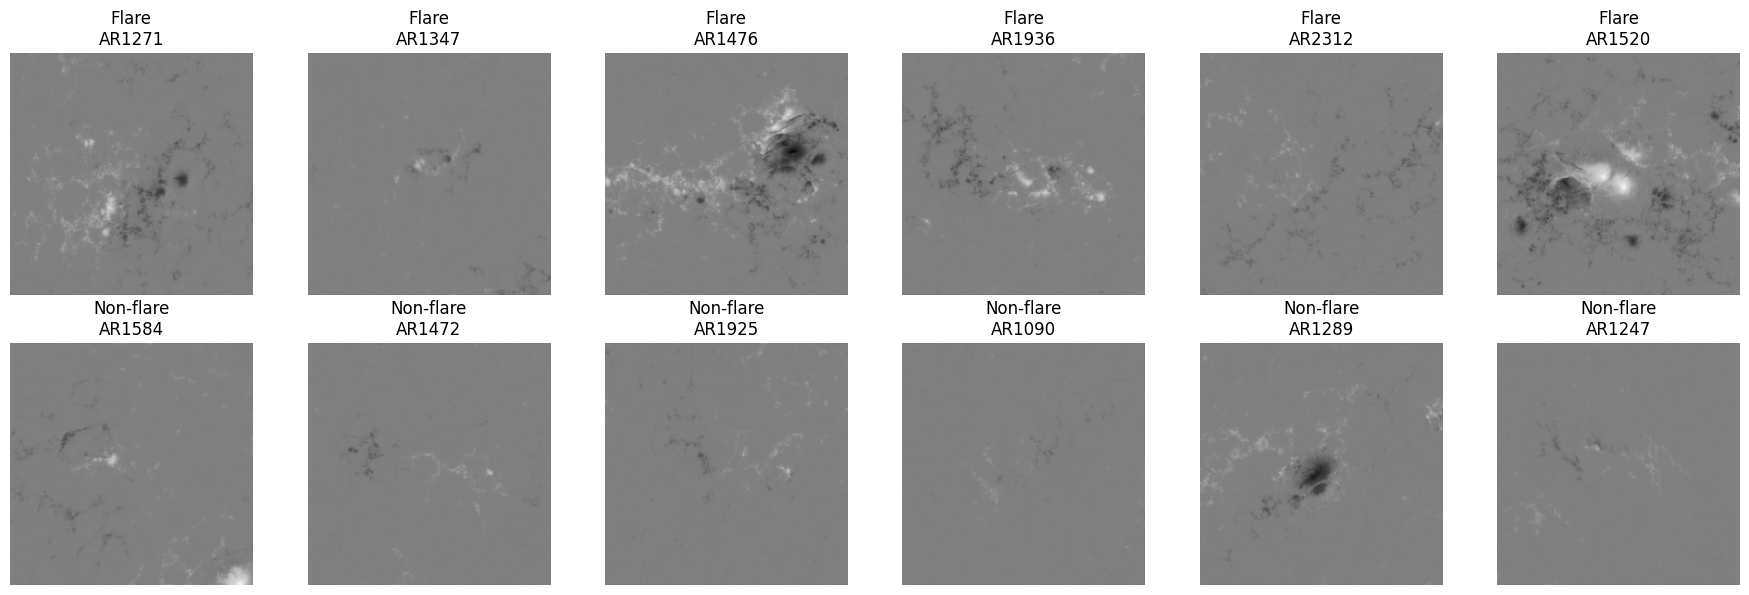

In [13]:
import matplotlib.pyplot as plt

def get_image_path(row):
    return IMAGE_ROOT_REAL / row["AR_number"] / row["filename"]

# Sample 6 flare and 6 non-flare images
flare_sample = df[df["label"] == 1].sample(6, random_state=1)
nonflare_sample = df[df["label"] == 0].sample(6, random_state=1)

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for i, (_, row) in enumerate(flare_sample.iterrows()):
    p = get_image_path(row)
    img = np.array(Image.open(p))
    axes[0, i].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[0, i].set_title(f"Flare\nAR{row['AR_number']}")
    axes[0, i].axis("off")

for i, (_, row) in enumerate(nonflare_sample.iterrows()):
    p = get_image_path(row)
    img = np.array(Image.open(p))
    axes[1, i].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[1, i].set_title(f"Non-flare\nAR{row['AR_number']}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [14]:
import hashlib
from collections import defaultdict

# Sample 300 images for corruption/duplicate check (checking all 950k would take too long)
check_sample = df.sample(300, random_state=42)

corrupted = []
hashes = defaultdict(list)

for _, row in check_sample.iterrows():
    p = get_image_path(row)
    if not p.exists():
        corrupted.append((str(p), "missing"))
        continue
    try:
        Image.open(p).verify()
        with open(p, "rb") as f:
            h = hashlib.md5(f.read()).hexdigest()
        hashes[h].append(str(p))
    except Exception as e:
        corrupted.append((str(p), str(e)))

print(f"Corrupted/missing in sample of 300: {len(corrupted)}")
dupes = {h: paths for h, paths in hashes.items() if len(paths) > 1}
print(f"Duplicate groups found: {len(dupes)}")

# --- AR-level leakage check: does the official split avoid overlap? ---
train_ar = pd.read_csv(DATA_ROOT / "List_of_AR_in_Train_Data_by_AR.csv", header=None)
val_ar = pd.read_csv(DATA_ROOT / "List_of_AR_in_Validation_data_by_AR.csv", header=None)
test_ar = pd.read_csv(DATA_ROOT / "List_of_AR_in_Test_Data_by_AR.csv", header=None)

train_ids = set(train_ar[0].astype(str))
val_ids = set(val_ar[0].astype(str))
test_ids = set(test_ar[0].astype(str))

print("Train ARs:", len(train_ids), "Val ARs:", len(val_ids), "Test ARs:", len(test_ids))
print("Train∩Val overlap:", train_ids & val_ids)
print("Train∩Test overlap:", train_ids & test_ids)
print("Val∩Test overlap:", val_ids & test_ids)

Corrupted/missing in sample of 300: 0
Duplicate groups found: 0
Train ARs: 1256 Val ARs: 157 Test ARs: 157
Train∩Val overlap: set()
Train∩Test overlap: set()
Val∩Test overlap: set()


In [15]:
report = f"""
BOUCHERON SOLAR FLARE DATASET — FINAL DATA REPORT
==================================================

SOURCE
Boucheron, Vincent, Grajeda, Wuest (New Mexico State University)
Labels/metadata DOI: 10.5061/dryad.jq2bvq898
Images DOI: 10.5281/zenodo.7775776
Paper: arxiv.org/abs/2305.09492
Permanent Kaggle Dataset: esayasmelaku/solar-flare-boucheron-c1-224

DATASET SUMMARY
Active regions: 1,570
Total images: 950,047
Image size: 224x224, grayscale (mode L), uint8
Date range: May 2010 - Dec 2018 (per README)
Label: 1 = GOES flare >C1.0 within 24hrs after image, 0 = no such flare
Class balance: 79.94% non-flare (759,465), 20.06% flare (190,582)
Images per AR: min 3, max 1080, mean ~605

DATA QUALITY (sample of 300 images)
Corrupted/missing: 0
Duplicates: 0

OFFICIAL SPLIT (verified, not assumed)
Train ARs: 1256, Val ARs: 157, Test ARs: 157
AR-level overlap between splits: NONE (verified via set intersection)
Conclusion: official split is leakage-safe at the AR level

TEMPORAL STRUCTURE
Filenames confirmed to include NOAA AR number and exact timestamp
(e.g. 1064_hmi.M_720s.20100501_000000_TAI...), cadence ~720 seconds (12 min),
consistent with README's stated acquisition cadence.

ML IMPLICATIONS
- Use the authors' official AR-level split (Train/Validation/Test_Data_by_AR_png_224.csv)
  rather than a random image-level split, to avoid leakage.
- 20%/80% class imbalance likely needs class weighting or resampling during training.
- Temporal modeling (CNN+GRU/LSTM per AR sequence) is feasible: real, evenly-spaced
  timestamped sequences exist per AR (confirmed, not assumed).
- Recommended next step: build a baseline single-frame CNN using the official split
  first, establish a benchmark, then evaluate whether adding temporal modeling improves
  on it — consistent with van der Sande et al. 2023's finding referenced in the project notes.
"""

print(report)
with open("/kaggle/working/data_report.txt", "w") as f:
    f.write(report)
print("\nReport saved to /kaggle/working/data_report.txt")


BOUCHERON SOLAR FLARE DATASET — FINAL DATA REPORT

SOURCE
Boucheron, Vincent, Grajeda, Wuest (New Mexico State University)
Labels/metadata DOI: 10.5061/dryad.jq2bvq898
Images DOI: 10.5281/zenodo.7775776
Paper: arxiv.org/abs/2305.09492
Permanent Kaggle Dataset: esayasmelaku/solar-flare-boucheron-c1-224

DATASET SUMMARY
Active regions: 1,570
Total images: 950,047
Image size: 224x224, grayscale (mode L), uint8
Date range: May 2010 - Dec 2018 (per README)
Label: 1 = GOES flare >C1.0 within 24hrs after image, 0 = no such flare
Class balance: 79.94% non-flare (759,465), 20.06% flare (190,582)
Images per AR: min 3, max 1080, mean ~605

DATA QUALITY (sample of 300 images)
Corrupted/missing: 0
Duplicates: 0

OFFICIAL SPLIT (verified, not assumed)
Train ARs: 1256, Val ARs: 157, Test ARs: 157
AR-level overlap between splits: NONE (verified via set intersection)
Conclusion: official split is leakage-safe at the AR level

TEMPORAL STRUCTURE
Filenames confirmed to include NOAA AR number and exact t